## **JURNAL MODUL 4**

In [21]:
import numpy as np
import matplotlib.pyplot as plt
import cv2 as cv
import pandas as pd

Kode diatas berfungsi untuk mengimpor library utama dalam pengolahan citra, di mana Numpy (np) menangani operasi matematis pada array piksel, Matplotlib (plt) bertugas memvisualisasikan gambar dan grafik secara interaktif, OpenCV (cv) digunakan untuk fungsi teknis seperti membaca file atau konversi warna, serta Pandas (pd) berperan penting dalam mengorganisir data numerik dari citra ke dalam bentuk tabel yang terstruktur, sehingga memudahkan analisis statistik maupun penyimpanan data hasil pemrosesan ke dalam format yang lebih rapi.

Kode dibawah membaca file gambar telapaktangan.jpeg menggunakan Matplotlib, lalu mengonversinya dari format berwarna (RGB) menjadi skala abu-abu (grayscale) menggunakan OpenCV melalui fungsi cv.cvtColor. Proses konversi ini menyederhanakan data gambar menjadi satu saluran warna untuk mempermudah pemrosesan citra digital. Terakhir, gambar grayscale tersebut ditampilkan ke layar menggunakan plt.imshow dengan parameter cmap='gray' agar visualisasinya tepat berwarna hitam-putih.

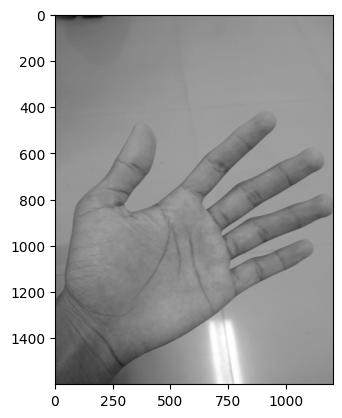

In [22]:
img_tangan = plt.imread('telapaktangan.jpeg')
img_tangan_gray = cv.cvtColor(img_tangan, cv.COLOR_RGB2GRAY)
plt.imshow(img_tangan_gray, cmap='gray')

In [23]:
def fungsi_dua(image, new_width, new_height):
    old_height, old_width = image.shape[:2]
    resized_image = np.zeros((new_height, new_width), dtype=np.uint8)
    for i in range(new_height):
        for j in range(new_width):
            x = int(j * old_width / new_width)
            y = int(i * old_height / new_height)
            resized_image[i, j] = image[y, x]
    return resized_image

Fungsi diatas digunakan untuk mengubah ukuran gambar secara manual. Cara kerjanya adalah dengan mengambil ukuran asli gambar, membuat wadah gambar baru yang kosong sesuai ukuran yang diinginkan, lalu mengisi setiap titik pada gambar baru tersebut dengan mengambil nilai titik terdekat dari gambar aslinya berdasarkan perbandingan skala ukuran yang baru dan yang lama.

In [24]:
prewittX = np.array([
    [-1, 0, 1],
    [-1, 0, 1],
    [-1, 0, 1]
], dtype=np.float32)

prewittY = np.array([
    [ 1,  1,  1],
    [ 0,  0,  0],
    [-1, -1, -1]
], dtype=np.float32)


sobelX = np.array([
    [-1, 0, 1],
    [-2, 0, 2],
    [-1, 0, 1]
], dtype=np.float32)

sobelY = np.array([
    [ 1,  2,  1],
    [ 0,  0,  0],
    [-1, -2, -1]
], dtype=np.float32)


robertsX = np.array([
    [1,  0],
    [0, -1]
], dtype=np.float32)

robertsY = np.array([
    [ 0, 1],
    [-1, 0]
], dtype=np.float32)

Kode diatas mendefinisikan berbagai jenis kernel atau matriks filter yang digunakan untuk teknik deteksi tepi (edge detection) pada citra dengan memanfaatkan perhitungan gradien piksel. Kernel Prewitt dan Sobel bekerja dengan mendeteksi perubahan intensitas pada arah horizontal (X) dan vertikal (Y) menggunakan matriks 3 x 3, di mana Sobel memberikan bobot lebih besar pada piksel pusat untuk menghasilkan efek deteksi yang lebih halus dan tahan terhadap noise. Sementara itu, kernel Roberts menggunakan matriks yang lebih kecil berukuran 2 x 2 secara diagonal untuk mendeteksi tepi secara cepat, meskipun lebih sensitif terhadap gangguan pada gambar. Seluruh kernel ini didefinisikan dengan tipe data float32 agar hasil perhitungan matematis antar piksel tetap akurat sebelum nantinya divisualisasikan kembali sebagai citra biner atau gradien.

In [25]:
def sobel_manual(img):
    h, w = img.shape
    hasil = np.zeros((h, w),dtype=np.float32)

    gx = np.array([
        [-1,0,1],
        [-2,0,2],
        [-1,0,1]
    ])

    gy = np.array([
        [-1,-2,-1],
        [ 0, 0, 0],
        [ 1, 2, 1]
    ])

    for i in range(1, h-1):
        for j in range(1, w-1):
            total_x = 0
            total_y = 0
            for ki in range(-1,2):
                for kj in range(-1,2):
                    pixel = img[i+ki, j+kj]
                    total_x += (pixel * gx[ki+1, kj+1])

                    total_y += (pixel * gy[ki+1, kj+1])

            gradien = (abs(total_x) + abs(total_y))
            hasil[i,j] = gradien

    nilai_min = hasil[0,0]
    nilai_max = hasil[0,0]

    for i in range(h):
        for j in range(w):
            if hasil[i,j] < nilai_min:
                nilai_min = hasil[i,j]
            if hasil[i,j] > nilai_max:
                nilai_max = hasil[i,j]

    normal = np.zeros((h, w),
                      dtype=np.uint8)
    for i in range(h):
        for j in range(w):
            normal[i,j] = int(
                ((hasil[i,j] - nilai_min) / (nilai_max - nilai_min)) * 255)

    for i in range(h):
        for j in range(w):
            normal[i,j] = int(normal[i,j] * 0.38)
    return normal

Fungsi diatas digunakan untuk mencari garis tepi pada gambar secara manual menggunakan metode Sobel. Caranya adalah dengan mengalikan setiap titik gambar dan tetangga sekitarnya menggunakan dua matriks khusus (gx dan gy) untuk mendeteksi perubahan warna secara mendatar dan tegak lurus. Setelah nilai perubahan tersebut digabungkan menjadi nilai kekuatan tepi, fungsi akan mencari nilai paling kecil dan paling besar untuk mengubah rentang warnanya agar pas antara 0 sampai 255. Terakhir, kecerahan gambar hasil deteksi tepi ini diturunkan dengan mengalikannya dengan angka 0.38 sebelum dikembalikan.

In [26]:
def convolution(img, kernel):
    if len(img.shape) == 3:
        height, width, channels = img.shape
    else:
        height, width = img.shape
        channels = 1
        img = img.reshape(height, width, 1)

    size = kernel.shape[0]
    pad_size = size // 2
    padded = np.pad(img, ((pad_size, pad_size), (pad_size, pad_size), (0, 0)), mode='constant')
    canvas = np.zeros_like(img).astype(np.float32)

    for c in range(channels):
        for i in range(height):
            for j in range(width):
                region = padded[i:i+size, j:j+size, c]
                canvas[i, j, c] = np.sum(region * kernel)
    
    canvas = np.clip(canvas, 0, 255).astype(np.uint8)
    
    if channels == 1:
        return canvas.reshape(height, width)
        
    return canvas

Fungsi diatas digunakan untuk menerapkan efek atau penyaringan pada gambar secara manual dengan teknik konvolusi. Di awal, fungsi ini memeriksa apakah gambarnya berwarna atau hitam-putih agar ukurannya bisa disesuaikan. Kemudian, pinggiran gambar diberi pembatas tambahan (padding) agar ukuran gambar tidak mengecil setelah diproses. Setelah itu, fungsi akan menggeser matriks penyaring (kernel) ke setiap bagian gambar, mengalikan nilai titik gambar dengan penyaring tersebut, dan menjumlahkannya. Terakhir, nilai hasilnya dibatasi agar tetap berada di rentang warna yang aman (0 sampai 255) sebelum dikembalikan ke bentuk ukuran semula.

In [27]:
def edge(img, kernelX, kernelY):

    gx = convolution(img, kernelX)
    gy = convolution(img, kernelY)

    canvas =  np.zeros_like(img, dtype=np.float32)
    canvas = np.abs(gx) + np.abs(gy)
    canvas = canvas * 255.0 / np.max(canvas)

    return np.clip(canvas, 0, 255).astype(np.uint8)

Fungsi diatas digunakan untuk memperjelas garis tepi pada gambar dengan menggabungkan dua hasil penyaringan. Pertama, fungsi memanggil rumus konvolusi yang sudah dibuat sebelumnya untuk mencari perubahan warna pada arah mendatar (gx) dan arah tegak lurus (gy). Hasil dari kedua arah tersebut kemudian digabungkan dengan menjumlahkan nilai mutlaknya. Agar gambar tidak terlalu gelap atau terlalu terang, nilainya diatur ulang berdasarkan nilai tertinggi yang ditemukan supaya pas dengan standar warna. Terakhir, nilainya dibatasi agar aman di rentang 0 sampai 255 sebelum diubah menjadi format gambar utuh.

In [28]:
def threshold_manual(img, nilai_threshold):
    h, w = img.shape
    hasil = np.zeros((h, w), dtype=np.uint8)
    for i in range(h):
        for j in range(w):
            if img[i,j] > nilai_threshold:
                hasil[i,j] = 255
            else:
                hasil[i,j] = 0
    return hasil

Fungsi diatas digunakan untuk mengubah gambar menjadi hitam-putih sepenuhnya berdasarkan batas nilai yang ditentukan. Cara kerjanya adalah dengan memeriksa setiap titik pada gambar satu per satu, jika warna titik tersebut lebih terang dari nilai batas yang kita masukkan, maka titik itu akan diubah menjadi putih bersih (255). Sebaliknya, jika titik tersebut sama atau lebih gelap dari nilai batas, maka akan langsung diubah menjadi hitam pekat (0).

Bagian kode dibawah merupakan tahapan untuk menjalankan semua fungsi yang sudah dibuat sebelumnya sekaligus menampilkan hasilnya. Pertama, gambar telapak tangan dibaca dan diubah menjadi abu-abu, lalu ukurannya dirubah menjadi 256 kali 256 piksel. Setelah itu, gambar yang sudah dirubah diproses menggunakan dua cara berbeda, yaitu dicari garis tepinya dengan metode Prewitt, serta dideteksi menggunakan metode Sobel yang hasilnya langsung diubah menjadi hitam-putih pekat dengan nilai batas 10. Di bagian akhir, empat gambar tersebut, mulai dari gambar asli, gambar setelah diubah ukurannya, hasil garis tepi, hingga hasil hitam-putih, ditampilkan bersamaan dalam satu baris berdampingan agar bisa langsung dibandingkan.

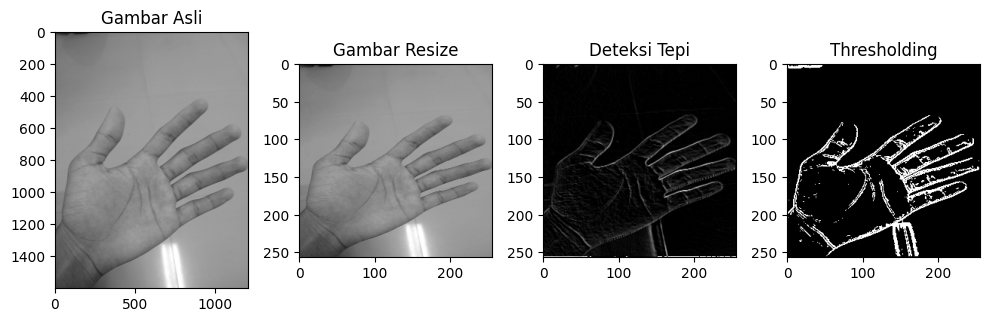

In [29]:
img_tangan = plt.imread('telapaktangan.jpeg')
img_tangan_gray = cv.cvtColor(img_tangan, cv.COLOR_RGB2GRAY)

img_tangan_resized = fungsi_dua(img_tangan_gray, 256, 256)

prewitt_tepi = edge(img_tangan_resized, prewittX, prewittY)

hasil_sobel = sobel_manual(img_tangan_resized)
threshold_10 = threshold_manual(hasil_sobel, 10)

plt.figure(figsize=(10, 5))
plt.subplot(1, 4, 1)
plt.imshow(img_tangan_gray, cmap='gray')
plt.title('Gambar Asli')

plt.subplot(1, 4, 2)
plt.imshow(img_tangan_resized, cmap='gray')
plt.title('Gambar Resize')

plt.subplot(1, 4, 3)
plt.imshow(prewitt_tepi, cmap='gray')
plt.title('Deteksi Tepi')

plt.subplot(1, 4, 4)
plt.imshow(threshold_10, cmap='gray')
plt.title('Thresholding')

plt.tight_layout()
plt.show()

In [30]:
def metode_satu(image, kernel):
    height, width = image.shape
    k_height, k_width = kernel.shape
    center = k_height // 2
    hasil = np.zeros((height, width))
    for i in range(center, height - center):
        for j in range(center, width - center):
            if image[i, j] == 255:
                for k in range(k_height):
                    for l in range(k_width):
                        if kernel[k, l] == 1:
                            hasil[i + k - center, j + l - center] = 255
            else:
                if hasil[i, j] != 255:
                    hasil[i, j] = 0
    return hasil

Fungsi diatas adalah proses dilasi yang digunakan untuk mempertebal atau memperluas bagian berwarna putih pada gambar hitam-putih. Cara kerjanya adalah dengan memeriksa setiap titik gambar, jika ditemukan titik yang berwarna putih bersih (255), maka seluruh titik di sekitarnya akan ikut diubah menjadi putih mengikuti pola cetakan khusus (kernel) yang bernilai 1. Jika titik aslinya bukan putih dan belum terkena efek penebalan dari titik tetangganya, maka bagian tersebut akan tetap dibiarkan berwarna hitam (0).

In [31]:
def metode_dua(image, kernel):
    height, width = image.shape
    k_height, k_width = kernel.shape
    center = k_height // 2
    hasil = np.zeros((height, width))
    for i in range(center, height - center):
        for j in range(center, width - center):
            cocok = True
            for k in range(k_height):
                for l in range(k_width):
                    if kernel[k, l] == 1 and image[i + k - center, j + l - center] == 0:
                        cocok = False
                        break
                if not cocok:
                    break
            if cocok:
                hasil[i, j] = 255
    return hasil

Fungsi diatas adalah proses erosi yang digunakan untuk menipiskan atau mengikis bagian berwarna putih pada gambar hitam-putih. Cara kerjanya adalah dengan mencocokkan pola cetakan khusus (kernel) pada setiap titik gambar, jika ada satu saja bagian dari pola cetakan bernilai 1 yang menempel pada area hitam (0) di gambar, maka titik tengahnya akan ikut berubah atau tetap menjadi hitam. Sebaliknya, titik tersebut hanya akan diubah menjadi putih bersih (255) jika seluruh pola cetakan benar-benar pas menempel pada area yang semuanya berwarna putih.

In [32]:
def metode_tiga(img):
    binary = (img > 0).astype(np.uint8)
    height, width = binary.shape
    changed = True

    while changed:
        changed = False
        hapus = []

        for i in range(1, height - 1):
            for j in range(1, width - 1):
                P1 = binary[i, j]
                if P1 != 1:
                    continue

                P2 = binary[i - 1, j]
                P3 = binary[i - 1, j + 1]
                P4 = binary[i, j + 1]
                P5 = binary[i + 1, j + 1]
                P6 = binary[i + 1, j]
                P7 = binary[i + 1, j - 1]
                P8 = binary[i, j - 1]
                P9 = binary[i - 1, j - 1]

                tetangga = [P2, P3, P4, P5, P6, P7, P8, P9]
                jumlah = np.sum(tetangga)

                transisi = 0
                urutan = tetangga + [P2]
                for k in range(8):
                    if urutan[k] == 0 and urutan[k + 1] == 1:
                        transisi += 1

                if (
                    2 <= jumlah <= 6 and
                    transisi == 1 and
                    P2 * P4 * P6 == 0 and
                    P4 * P6 * P8 == 0
                ):
                    hapus.append((i, j))

        if hapus:
            changed = True
            for i, j in hapus:
                binary[i, j] = 0

        hapus = []

        for i in range(1, height - 1):
            for j in range(1, width - 1):
                P1 = binary[i, j]
                if P1 != 1:
                    continue

                P2 = binary[i - 1, j]
                P3 = binary[i - 1, j + 1]
                P4 = binary[i, j + 1]
                P5 = binary[i + 1, j + 1]
                P6 = binary[i + 1, j]
                P7 = binary[i + 1, j - 1]
                P8 = binary[i, j - 1]
                P9 = binary[i - 1, j - 1]

                tetangga = [P2, P3, P4, P5, P6, P7, P8, P9]
                jumlah = np.sum(tetangga)

                transisi = 0
                urutan = tetangga + [P2]
                for k in range(8):
                    if urutan[k] == 0 and urutan[k + 1] == 1:
                        transisi += 1

                if (
                    2 <= jumlah <= 6 and
                    transisi == 1 and
                    P2 * P4 * P8 == 0 and
                    P2 * P6 * P8 == 0
                ):
                    hapus.append((i, j))

        if hapus:
            changed = True
            for i, j in hapus:
                binary[i, j] = 0

    return binary * 255

Fungsi diatas digunakan untuk menipiskan objek putih pada gambar hingga menyisakan bentuk kerangkanya saja. Cara kerjanya adalah dengan memeriksa delapan titik tetangga di sekeliling setiap titik putih secara berulang-ulang melalui dua tahap pengecekan. Titik putih di bagian pinggir akan dihapus atau diubah menjadi hitam jika memenuhi syarat jumlah tetangga dan jumlah perubahan pola warna tertentu, tanpa memutus garis utama gambar. Proses ini akan terus berjalan dalam perulangan sampai tidak ada lagi titik pinggiran yang bisa dihapus, sehingga menghasilkan garis rangka yang tipis.

In [33]:
def metode_empat(img, kernel, iterasi=1):
    hasil = img.copy()
    for _ in range(iterasi):
        hasil = metode_satu(hasil, kernel)
    return hasil

Fungsi diatas digunakan untuk melakukan proses penebalan gambar secara berulang-ulang sesuai jumlah yang diinginkan. Cara kerjanya adalah dengan menyalin gambar asli terlebih dahulu agar data aslinya tidak rusak, kemudian menjalankan fungsi penebalan yang pertama (metode_satu) di dalam sebuah perulangan. Setiap kali perulangan berjalan, hasil penebalan sebelumnya akan dipakai kembali untuk ditebalkan lagi, sehingga objek putih pada gambar akan menjadi semakin tebal di setiap tahapannya.

Kode dibawah digunakan untuk melakukan berbagai operasi perubahan bentuk (morfologi) pada citra biner telapak tangan menggunakan cetakan pola (kernel) berukuran 3x3, lalu menampilkan perbandingannya. Jika dibandingkan dengan citra asli sebelum proses morfologi dilakukan, terlihat perbedaan yang jelas pada masing-masing hasil. Citra Dilasi dan Thickening membuat garis putih telapak tangan menjadi lebih gemuk dan tebal dari aslinya. Sebaliknya, citra Erosi mengikis objek putih hingga menyisakan bentuk samar telapak tangan berupa bintik-bintik kecil, yang kemudian berdampak pada citra Opening (proses erosi lalu dilasi) yang berhasil membersihkan bercak kotor (noise) di luar objek utama dengan rapi. Sementara itu, citra Closing berhasil menutup lubang-lubang kecil di dalam objek dan menyambung kembali garis yang sempat terputus. Terakhir, citra Thinning mengosongkan bagian dalam objek hingga menyisakan garis rangka telapak tangan yang tipis, yang kemudian diperjelas batas-batasnya pada hasil Gradient Morph.

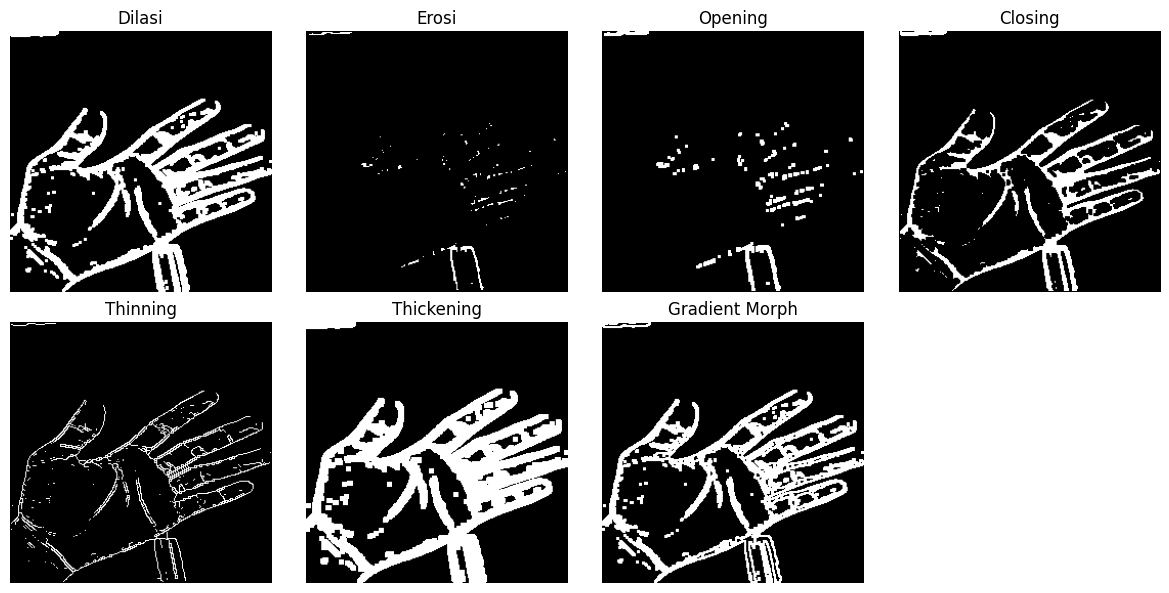

In [34]:
kernel_3x3 = np.array([
    [1, 1, 1],
    [1, 1, 1],
    [1, 1, 1]
], dtype = np.float32)

tangan_dilasi = metode_satu(threshold_10, kernel_3x3)
tangan_erosi = metode_dua(threshold_10, kernel_3x3)

tangan_opening = metode_satu(tangan_erosi, kernel_3x3)
tangan_closing = metode_dua(tangan_dilasi, kernel_3x3)

tangan_thinning = metode_tiga(threshold_10)
tangan_thickening = metode_empat(threshold_10, kernel_3x3, iterasi=2)

gradient_morph = tangan_dilasi - tangan_erosi

plt.figure(figsize=(12, 6))
plt.subplot(2, 4, 1)
plt.imshow(tangan_dilasi, cmap='gray')
plt.title('Dilasi')
plt.axis('off')

plt.subplot(2, 4, 2)
plt.imshow(tangan_erosi, cmap='gray')
plt.title('Erosi')
plt.axis('off')

plt.subplot(2, 4, 3)
plt.imshow(tangan_opening, cmap='gray')
plt.title('Opening')
plt.axis('off')

plt.subplot(2, 4, 4)
plt.imshow(tangan_closing, cmap='gray')
plt.title('Closing')
plt.axis('off')

plt.subplot(2, 4, 5)
plt.imshow(tangan_thinning, cmap='gray')
plt.title('Thinning')
plt.axis('off')

plt.subplot(2, 4, 6)
plt.imshow(tangan_thickening, cmap='gray')
plt.title('Thickening')
plt.axis('off')

plt.subplot(2, 4, 7)
plt.imshow(gradient_morph, cmap='gray')
plt.title('Gradient Morph')
plt.axis('off')

plt.tight_layout()
plt.show()

Bagian kode dibawah digunakan untuk membuat matriks cetakan pola (kernel) baru berukuran 5x5 yang seluruh nilainya berisi angka 1, lalu menerapkannya ke berbagai fungsi morfologi seperti dilasi, erosi, opening, closing, thinning, hingga thickening pada gambar telapak tangan biner. Setelah semua fungsi selesai memproses gambar dengan cetakan baru tersebut, hasilnya langsung disusun berdampingan dalam beberapa kotak visualisasi menggunakan perintah subplot dari Matplotlib agar efek perubahan bentuknya bisa langsung dibandingkan.

Perubahan ukuran cetakan dari 3x3 menjadi 5x5 ini memberikan dampak yang sangat besar terhadap bentuk, detail, ketebalan, dan kebersihan gambar. Pada hasil dilasi dan thickening, cetakan 5x5 membuat ketebalan objek putih bertambah jauh lebih drastis, yang mana akibatnya, detail celah kecil pada jari-jari menjadi tertutup karena area putihnya meluas dan menyatu. Sebaliknya, pada proses erosi, cetakan 3x3 masih menyisakan struktur samar berupa titik-titik kecil, sedangkan pada cetakan 5x5 objek terkikis habis tanpa sisa karena efek pengikisannya terlalu kuat, yang kemudian membuat hasil opening kehilangan hampir seluruh bentuk utama tangan. Sementara itu, pada proses closing, lubang-lubang kosong di dalam telapak tangan tertutup jauh lebih padat dan sempurna, sedangkan untuk hasil thinning dan gradient morph, garis rangka yang terbentuk tetap tipis namun memiliki sedikit perbedaan lekukan karena mengikuti bentuk dasar objek yang sudah berubah sejak awal proses.

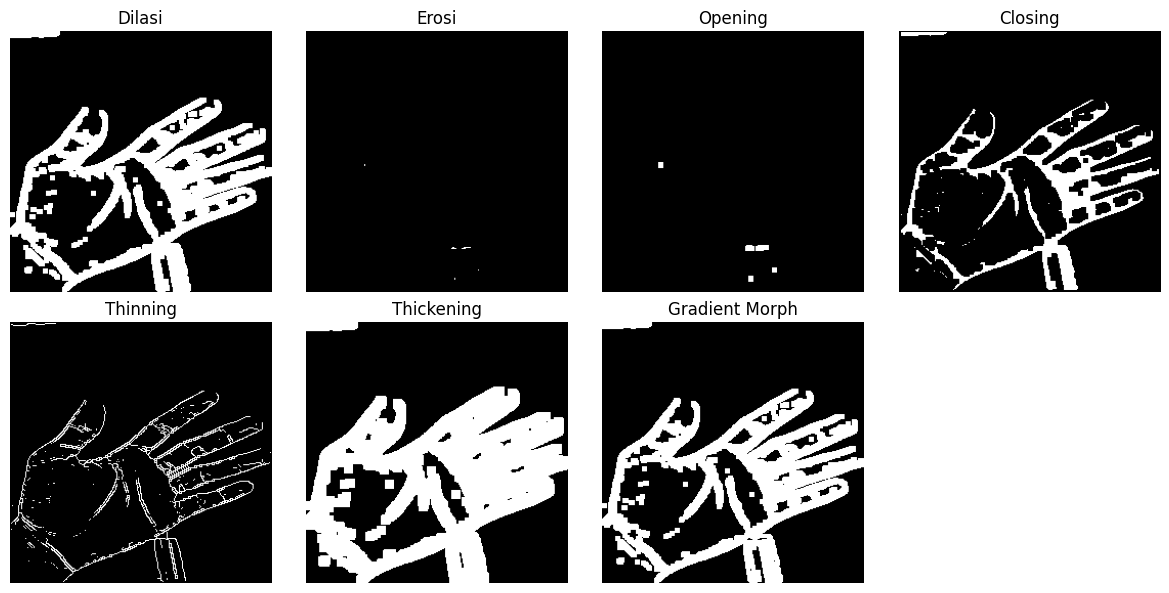

In [35]:
kernel_5x5 = np.array([
    [1, 1, 1, 1, 1],
    [1, 1, 1, 1, 1],
    [1, 1, 1, 1, 1],
    [1, 1, 1, 1, 1],
    [1, 1, 1, 1, 1]
], dtype = np.float32)

tangan_dilasi2 = metode_satu(threshold_10, kernel_5x5)
tangan_erosi2 = metode_dua(threshold_10, kernel_5x5)

tangan_opening2 = metode_satu(tangan_erosi2, kernel_5x5)
tangan_closing2 = metode_dua(tangan_dilasi2, kernel_5x5)

tangan_thinning2 = metode_tiga(threshold_10)
tangan_thickening2 = metode_empat(threshold_10, kernel_5x5, iterasi=2)

gradient_morph2 = tangan_dilasi2 - tangan_erosi2

plt.figure(figsize=(12, 6))
plt.subplot(2, 4, 1)
plt.imshow(tangan_dilasi2, cmap='gray')
plt.title('Dilasi')
plt.axis('off')

plt.subplot(2, 4, 2)
plt.imshow(tangan_erosi2, cmap='gray')
plt.title('Erosi')
plt.axis('off')

plt.subplot(2, 4, 3)
plt.imshow(tangan_opening2, cmap='gray')
plt.title('Opening')
plt.axis('off')

plt.subplot(2, 4, 4)
plt.imshow(tangan_closing2, cmap='gray')
plt.title('Closing')
plt.axis('off')

plt.subplot(2, 4, 5)
plt.imshow(tangan_thinning2, cmap='gray')
plt.title('Thinning')
plt.axis('off')

plt.subplot(2, 4, 6)
plt.imshow(tangan_thickening2, cmap='gray')
plt.title('Thickening')
plt.axis('off')

plt.subplot(2, 4, 7)
plt.imshow(gradient_morph2, cmap='gray')
plt.title('Gradient Morph')
plt.axis('off')

plt.tight_layout()
plt.show()

Bagian kode dibawah digunakan untuk menggabungkan beberapa operasi morfologi sekaligus secara berurutan (kombinasi operasi) pada citra biner telapak tangan menggunakan kernel 3x3. Di sini, hasil dari operasi tunggal yang sudah ada sebelumnya dikombinasikan kembali, seperti melakukan proses closing setelah opening, melakukan opening setelah closing, serta menambahkan proses dilasi atau erosi langsung setelah operasi tunggal selesai. Hasil akhir dari keempat kombinasi ini kemudian ditampilkan dalam susunan grid 2x2 menggunakan pustaka Matplotlib untuk mempermudah pengamatan visual.

Jika dianalisis terhadap perubahan yang terjadi dibandingkan dengan hasil operasi morfologi tunggal dan citra asli, kombinasi operasi ini memberikan pengaruh yang sangat signifikan:

- Pengurangan Noise: Kombinasi yang diawali dengan opening (seperti Opening + Closing dan Opening + Dilasi) sangat efektif dalam menghapus bintik-bintik kotor (noise) di luar area tangan sejak awal proses, sehingga latar belakangnya menjadi jauh lebih bersih dibandingkan citra asli.

- Bentuk dan Ketebalan Objek: Urutan operasi sangat menentukan bentuk akhir objek. Pada Opening + Dilasi, bentuk objek terlihat berupa potongan garis yang lebih gemuk. Sementara pada kombinasi Closing + Opening dan Closing + Erosi, struktur utama bentuk telapak tangan dan jemari jauh lebih terjaga dan menyatu dibandingkan jika hanya menggunakan erosi tunggal, meskipun ketebalan garisnya menjadi sedikit lebih ramping karena efek pengikisan di akhir tahapan.

- Kejelasan Batas Objek: Secara keseluruhan, kombinasi operasi ini menghasilkan batas objek yang lebih tegas dan jelas. Celah-celah kosong di dalam struktur tangan berhasil diminimalisir oleh proses closing, sedangkan pinggiran luar objek yang tidak rata berhasil dirapikan, membuat penegasan batas antara objek telapak tangan dan latar belakang hitam menjadi lebih kontras dan rapi.

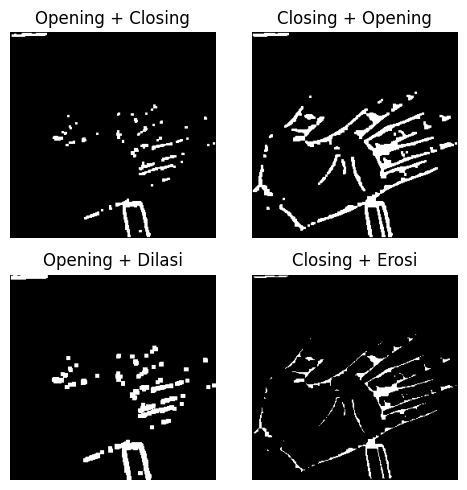

In [36]:
tangan_opening_closing = metode_dua(metode_satu(tangan_opening, kernel_3x3), kernel_3x3)
tangan_closing_opening = metode_satu(metode_dua(tangan_closing, kernel_3x3), kernel_3x3)
tangan_opening_dilasi = metode_satu(tangan_opening, kernel_3x3)
tangan_closing_erosi = metode_dua(tangan_closing, kernel_3x3)

plt.figure(figsize=(5, 5))

plt.subplot(2, 2, 1)
plt.imshow(tangan_opening_closing, cmap='gray')
plt.title('Opening + Closing')
plt.axis('off')

plt.subplot(2, 2, 2)
plt.imshow(tangan_closing_opening, cmap='gray')
plt.title('Closing + Opening')
plt.axis('off')

plt.subplot(2, 2, 3)
plt.imshow(tangan_opening_dilasi, cmap='gray')
plt.title('Opening + Dilasi')
plt.axis('off')

plt.subplot(2, 2, 4)
plt.imshow(tangan_closing_erosi, cmap='gray')
plt.title('Closing + Erosi')
plt.axis('off')

plt.tight_layout()
plt.show()

In [37]:
def filter(img, size, mode):
    height, width = img.shape
    pad = size // 2
    padded = np.pad(img, pad, mode='edge')
    canvas = np.zeros_like(img, dtype=np.uint8)
    
    match mode:
        case 'mean':
            area = size * size
            for i in range(height):
                for j in range(width):
                    region = padded[i:i+size, j:j+size]
                    canvas[i, j] = np.sum(region) // area
                    
        case 'median':
            for i in range(height):
                for j in range(width):
                    region = padded[i:i+size, j:j+size]
                    region_flat = np.sort(region.ravel())
                    canvas[i, j] = region_flat[(size * size) // 2]
                    
        case 'modus':
            for i in range(height):
                for j in range(width):
                    region = padded[i:i+size, j:j+size]
                    values = region.ravel()
                    count = {}
                    for val in values:
                        if val in count:
                            count[val] += 1
                        else:
                            count[val] = 1
                            
                    max_count = 0
                    mode_val = 0
                    for val, freq in count.items():
                        if freq > max_count:
                            max_count = freq
                            mode_val = val
                            
                    canvas[i, j] = mode_val
                    
    return canvas

Fungsi diatas digunakan untuk melakukan penyaringan (filtering) pada gambar guna mengurangi bintik piksel pengganggu (noise) dengan menambahkan bingkai tambahan di sekeliling gambar asli agar area pinggir tidak terpotong, kemudian memprosesnya berdasarkan tiga pilihan metode statistik. Jika mode rata-rata (mean) dipilih, fungsi akan menghitung nilai rata-rata piksel di area sekitar sehingga menghasilkan efek gambar yang lebih halus atau sedikit buram, jika mode nilai tengah (median) dipilih, piksel tetangga akan diurutkan dari terkecil ke terbesar untuk diambil nilai tengahnya yang sangat ampuh menghapus noda hitam-putih tanpa merusak ketajaman garis, sedangkan jika mode sering muncul (modus) dipilih, fungsi akan mencatat frekuensi kemunculan setiap warna menggunakan bantuan kamus pencatat lalu menerapkan warna dengan tingkat kemunculan paling tinggi pada piksel tersebut.

Rangkaian kode dibawah merupakan sebuah alur pemrosesan yang bertujuan untuk mengekstraksi dan mempertegas struktur garis tepi (kontur) luar telapak tangan dari citra biner. Alur ini menggabungkan teknik binerisasi, operasi morfologi berulang, penyaringan statistik, hingga ekstraksi kontur akhir menggunakan metode Gradient Morph.

Berdasarkan kodenya, berikut adalah analisis mengenai alasan penggunaan setiap proses beserta pengaruhnya terhadap hasil akhir citra:

- 1. Binerisasi (Thresholding)
>Alasan Penggunaan: Setelah ukuran citra disesuaikan dan deteksi tepi Sobel dilakukan (pada baris awal kode), fungsi threshold_manual dengan nilai batas 10 digunakan untuk memisahkan informasi tepi secara tegas menjadi hitam (0) dan putih (255).

>Pengaruh: Menghasilkan citra biner kontras tinggi yang mengisolasi bentuk tepi tangan. Namun, karena nilai ambang batasnya cukup sensitif, garis tepi yang terbentuk masih tipis, memiliki banyak celah yang putus-putus, serta menyisakan bercak kotoran (noise) halus di sekitarnya.

- 2. Penebalan (Thickening)
>Alasan Penggunaan: Fungsi metode_satu (dilasi) dijalankan di awal untuk memperluas jangkauan piksel putih pada garis tepi yang sebelumnya terputus-putus.

>Pengaruh: Garis kontur tangan menjadi jauh lebih gemuk dan tebal. Pelebaran ini berhasil menyambung kembali sebagian besar celah kosong pada jari-jari, meski di sisi lain membuat bintik noise di latar belakang ikut membesar.

- 3. Penutupan Celah (Closing)
>Alasan Penggunaan: Fungsi metode_dua (erosi) dijalankan langsung setelah penebalan untuk melengkapi proses closing. Alasan utamanya adalah untuk mengikis kembali pinggiran objek yang terlalu bengkak tanpa membuka celah biner yang sudah berhasil disambung sebelumnya.

>Pengaruh: Struktur bentuk garis tangan menjadi lebih rapi dan terkonsolidasi, sementara lubang-lubang kosong di dalam garis tepi berhasil tertutup dengan baik

- 4 & 5. Pembersihan Berulang (Median Filter 1 & Median Filter 2)
>Alasan Penggunaan: Fungsi filter dengan mode 'median' dijalankan sebanyak dua kali berturut-turut. Alasan pengulangan ini adalah untuk mematangkan pembersihan citra, filter median sangat efektif dalam mengeliminasi bintik kotoran (salt-and-pepper noise) tanpa mengaburkan ketajaman batas garis utama.

>Pengaruh: Pada tahapan Filter 1 dan Filter 2, terlihat perubahan yang signifikan di mana bintik-bintik noise terisolasi di area luar tangan berkurang drastis secara bertahap, membuat latar belakang hitam menjadi jauh lebih bersih dan kontur tepi tangan tampak lebih solid.

- 6. Ekstraksi Akhir (Gradient Morph)
>Alasan Penggunaan: Proses akhir dilakukan dengan mencari selisih antara hasil dilasi final dan erosi final (dilasi_final - erosi_final). Alasan digunakannya metode gradien morfologi ini adalah untuk mengosongkan bagian dalam dari garis biner yang sudah tebal, sehingga yang tersisa benar-benar hanya guratan pembatasnya saja.

>Pengaruh terhadap Hasil Akhir: Menghasilkan citra "Gradient Morph" yang bersih. Pengaruh akhirnya adalah terbentuknya garis kontur telapak tangan yang sangat jelas, tajam, utuh, dan bebas dari gangguan bintik noise, memberikan representasi outline tangan yang sempurna untuk kebutuhan analisis bentuk tingkat lanjut.

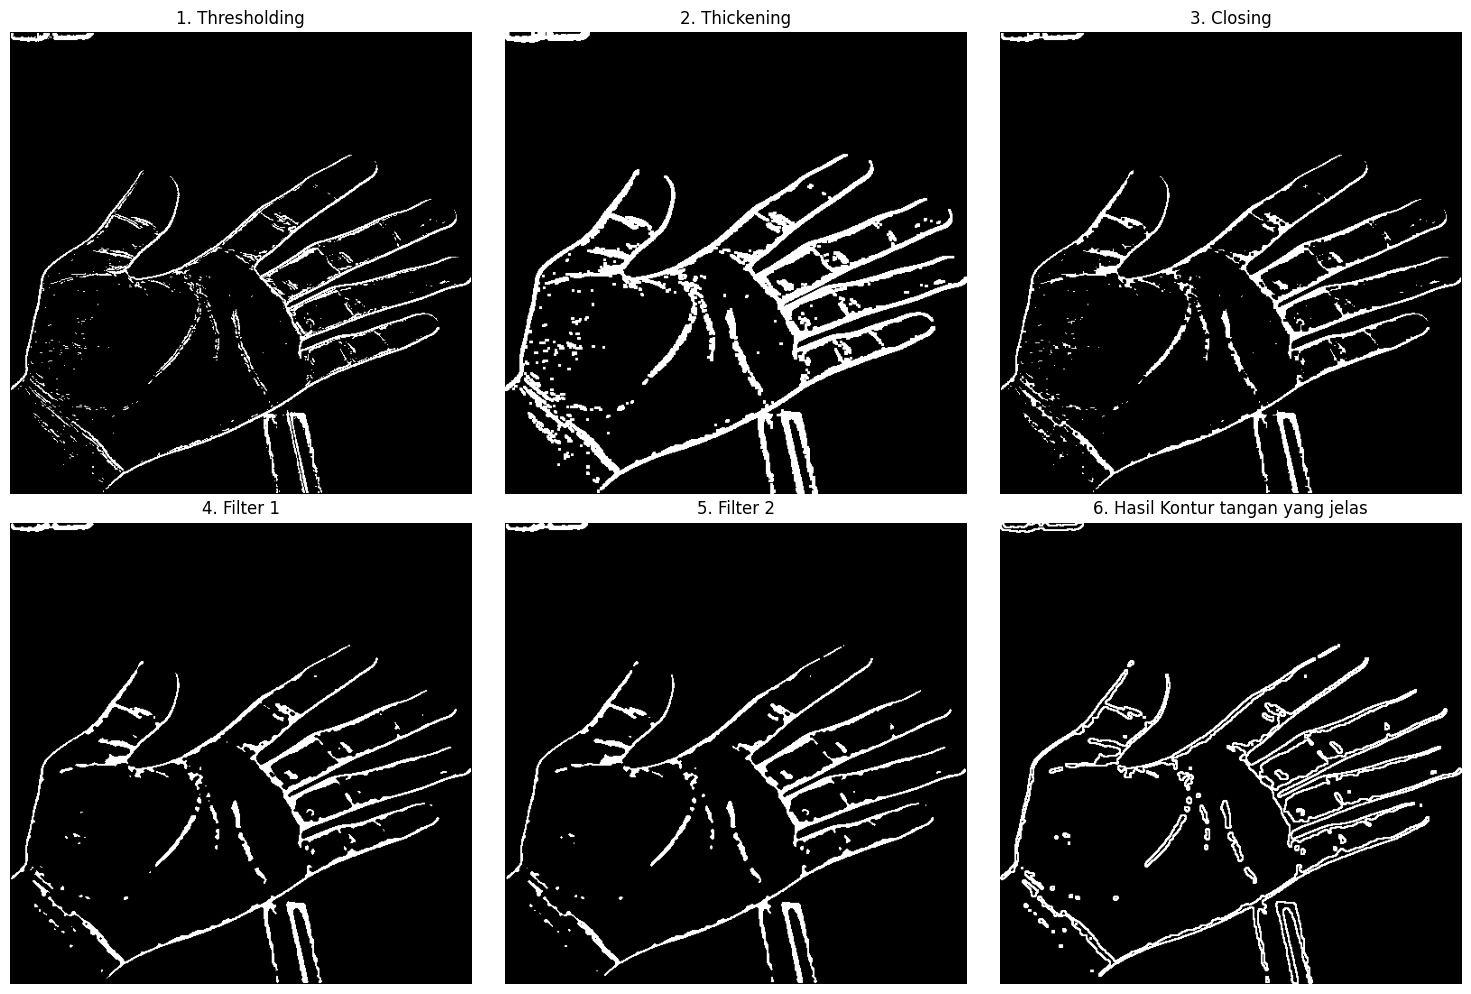

In [38]:
img_target_size = fungsi_dua(img_tangan_gray, 512, 512)
tepi_sobel = sobel_manual(img_target_size)

proses_1_thresh = threshold_manual(tepi_sobel, 10)

proses_2_thick = metode_satu(proses_1_thresh, kernel_3x3)

proses_3_closing = metode_dua(proses_2_thick, kernel_3x3)

proses_4_median1 = filter(proses_3_closing, 3, 'median') 

proses_5_median2 = filter(proses_4_median1, 3, 'median')

dilasi_final = metode_satu(proses_5_median2, kernel_3x3)
erosi_final = metode_dua(proses_5_median2, kernel_3x3)
proses_6_gradmorph = (dilasi_final - erosi_final).astype(np.uint8)

plt.figure(figsize=(15, 10))

plt.subplot(2, 3, 1)
plt.imshow(proses_1_thresh, cmap='gray')
plt.title('1. Thresholding')
plt.axis('off')

plt.subplot(2, 3, 2)
plt.imshow(proses_2_thick, cmap='gray')
plt.title('2. Thickening')
plt.axis('off')

plt.subplot(2, 3, 3)
plt.imshow(proses_3_closing, cmap='gray')
plt.title('3. Closing')
plt.axis('off')

plt.subplot(2, 3, 4)
plt.imshow(proses_4_median1, cmap='gray')
plt.title('4. Filter 1')
plt.axis('off')

plt.subplot(2, 3, 5)
plt.imshow(proses_5_median2, cmap='gray')
plt.title('5. Filter 2')
plt.axis('off')

plt.subplot(2, 3, 6)
plt.imshow(proses_6_gradmorph, cmap='gray')
plt.title('6. Hasil Kontur tangan yang jelas')
plt.axis('off')

plt.tight_layout()
plt.show()

### **KESIMPULAN**

Berdasarkan seluruh rangkaian percobaan yang telah dilakukan pada praktikum Modul 4 ini, dapat ditarik beberapa kesimpulan mengenai implementasi dan analisis operasi morfologi pada citra:

- Operasi morfologi dasar sangat bergantung pada interaksi antara citra biner dan matriks cetakan pola (kernel). Dilasi (metode_satu) terbukti berfungsi untuk memperluas, mempertebal, dan menyambung struktur objek putih yang terputus. Sebaliknya, Erosi (metode_dua) berfungsi untuk mengikis, menipiskan, dan memperkecil dimensi objek putih dengan cara menghilangkan piksel pinggiran.

- Ukuran kernel menentukan intensitas perubahan bentuk citra. Penggunaan kernel yang lebih besar (5x5) memberikan efek perubahan yang jauh lebih drastis dan agresif dibandingkan kernel 3x3. Pada dilasi/thickenning 5x5, objek menjadi sangat tebal hingga menutup detail celah jari. Sedangkan pada erosi 5x5, efek pengikisan terlalu kuat hingga berisiko menghilangkan detail struktur utama objek secara keseluruhan.

- Operasi tunggal sering kali memiliki efek samping, namun kombinasi berurutan mampu memberikan hasil yang lebih optimal. Proses Opening (erosi diikuti dilasi) sangat efektif untuk membersihkan bintik kotoran (noise) di latar belakang tanpa merusak bentuk asli objek. Sementara Closing (dilasi diikuti erosi) sangat baik untuk menutup lubang-lubang kosong di dalam objek dan mempertegas keutuhan struktur.

- Penggabungan operasi seperti Opening + Closing atau Closing + Opening menghasilkan citra yang jauh lebih bersih, utuh, dan memiliki batas objek yang kontras serta tegas. Urutan penempatan fungsi di dalam kode sangat menentukan hasil akhir, operasi yang diawali dengan opening akan memprioritaskan kebersihan latar belakang, sedangkan yang diawali closing akan memprioritaskan keutuhan bentuk objek.

- Proses Thinning (metode_tiga) berhasil mereduksi objek biner hingga menyisakan bentuk kerangka dasarnya yang setebal 1 piksel tanpa memutus kontinuitas garis. Ketika dikombinasikan dengan operasi deteksi tepi (Gradient Morph), batas-batas struktural dari kerangka tersebut dapat disajikan dengan informasi tepi yang jauh lebih jelas dan tajam.